In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm
from skbio.stats.distance import mantel


from src.datasets import QM9Dataset

In [4]:
qm9 = QM9Dataset(limit=5_000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["mace", "acsf", "transformer", "chemprop", "soap", "onehot", "morgan"])
df = qm9.load()

2026-05-07 08:26:58.675 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-07 08:27:00.025 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-05-07 08:27:00.034 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-05-07 08:27:00.037 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-05-07 08:27:36.029 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-05-07 08:28:30.427 | INFO     | src.features:compute_selfies_onehot:284 - Computing One-Hot Encodings...
2026-05-07 08:28:32.255 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-07 08:28:47.361 | SUCCESS  | src.datasets:add_soap:1243 - Added SOAP embeddings and matrices.
2026-05-07 08:28:47.383 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-07 08:28:54.107 | SUCCESS  | src.datasets:add_acsf:1262 - Added ACSF embeddings and matrices.
2026-05-07 08:28:54.110 | INFO     | src.features:compute_mace_outputs:678 - Computing MACE embeddings (model=medium, batch_size=32)...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.loa

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
2026-05-07 08:46:03.667 | SUCCESS  | src.datasets:add_mace:1286 - Added MACE embeddings and matrices.
2026-05-07 08:46:03.765 | INFO     | src.features:compute_chemprop_embeddings:709 - Computing Chemprop embeddings on mps...
2026-05-07 08:46:03.771 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-07 08:46:03.813 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-07 08:46:03.993 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weig

In [ ]:
onehot_matrix = qm9.get_distance_matrix(
    descriptor='onehot',
    dist_type="jaccard",
    force_calculate=True
)

morgan_matrix = qm9.get_distance_matrix(
    descriptor='morgan',
    dist_type="jaccard",
    force_calculate=True
)

soap_matrix = qm9.get_distance_matrix(
    descriptor='soap',
    dist_type="soap_kernel",
    force_calculate=True,
)

acsf_matrix = qm9.get_distance_matrix(
    descriptor='acsf',
    dist_type="euclidean",
    force_calculate=True,
)

transformer_matrix = qm9.get_distance_matrix(
    descriptor='transformer',
    dist_type="euclidean",
    force_calculate=True,
    pca_components=8,
)

chemprop_matrix = qm9.get_distance_matrix(
    descriptor='chemprop',
    dist_type="euclidean",
    force_calculate=True,
    pca_components=8,
)

2026-04-21 10:10:12.820 | INFO     | src.datasets:get_distance_matrix:1012 - Calculating distance matrix for selfies_onehot using jaccard distance.
2026-04-21 10:11:07.242 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_selfies_onehot_jaccard.npy
2026-04-21 10:11:07.335 | INFO     | src.datasets:get_distance_matrix:1012 - Calculating distance matrix for morgan using jaccard distance.
2026-04-21 10:11:45.532 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_morgan_jaccard.npy
2026-04-21 10:11:45.585 | INFO     | src.datasets:get_distance_matrix:991 - Applying PCA to retain 95.00% of variance.
2026-04-21 10:11:52.573 | INFO     | src.datasets:get_distance_matrix:1001 - PCA reduced 'soap' dimensions from 2240 to 8
2026-04-21 10:11:52.606 | INFO     | src.datasets:get_distance_matrix:1012 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-21 10:11:53.160 | SUCCESS  | src.distance:_compute_

In [ ]:
matrices = {
    "OneHot": onehot_matrix,
    "Morgan": morgan_matrix,
    "SOAP": soap_matrix,
    "ACSF": acsf_matrix,
    "Transformer": transformer_matrix,
    "Chemprop": chemprop_matrix
}

names = list(matrices.keys())
n = len(names)

# Initialize results matrix with 1.0 on the diagonal 
# (a metric perfectly correlates with itself)
results = np.zeros((n, n))
np.fill_diagonal(results, 1.0)

# Generate all unique pairs of indices (e.g., (0,1), (0,2)...)
# This prevents calculating A vs B and then redundantly calculating B vs A
pairs = list(combinations(range(n), 2))

# Define the worker function for the parallel pool
def compute_pair(i, j):
    """
    Runs the scikit-bio mantel test on a pair of matrices.
    """
    # 1. Cast the matrices to 64-bit floats (C 'double'). 
    # This simultaneously creates a writable copy, bypassing joblib's lock.
    mat_i = matrices[names[i]].astype(np.float64)
    mat_j = matrices[names[j]].astype(np.float64)
    
    # 2. Ensure the matrices are strictly "hollow" (diagonal == 0.0)
    np.fill_diagonal(mat_i, 0.0)
    np.fill_diagonal(mat_j, 0.0)

    # 3. Run the optimized mantel test
    r, p, _ = mantel(
        mat_i, 
        mat_j, 
        method='pearson', 
        permutations=999 
    )
    return i, j, r

print(f"Executing {len(pairs)} pairwise Mantel comparisons...")


# Loop through the pairs one by one using tqdm for a progress bar
for i, j in tqdm(pairs, desc="Computing pairs"):
    
    # Run the compute function
    _, _, r = compute_pair(i, j)
    
    # Immediately assign the result to the matrix (mirroring across the diagonal)
    results[i, j] = results[j, i] = r

# Convert to DataFrame for visualization
mantel_df = pd.DataFrame(results, index=names, columns=names)

print("\nFinal Mantel Correlation Matrix:")
print(mantel_df)

Executing 15 pairwise Mantel comparisons...


Computing pairs: 100%|██████████| 15/15 [10:50<00:00, 43.35s/it]


Final Mantel Correlation Matrix:
               OneHot    Morgan      SOAP      ACSF  Transformer  Chemprop
OneHot       1.000000  0.118325  0.163378  0.399750     0.133432  0.222502
Morgan       0.118325  1.000000  0.322366  0.350500     0.353650  0.495417
SOAP         0.163378  0.322366  1.000000  0.497399     0.288843  0.359477
ACSF         0.399750  0.350500  0.497399  1.000000     0.414328  0.658603
Transformer  0.133432  0.353650  0.288843  0.414328     1.000000  0.512447
Chemprop     0.222502  0.495417  0.359477  0.658603     0.512447  1.000000


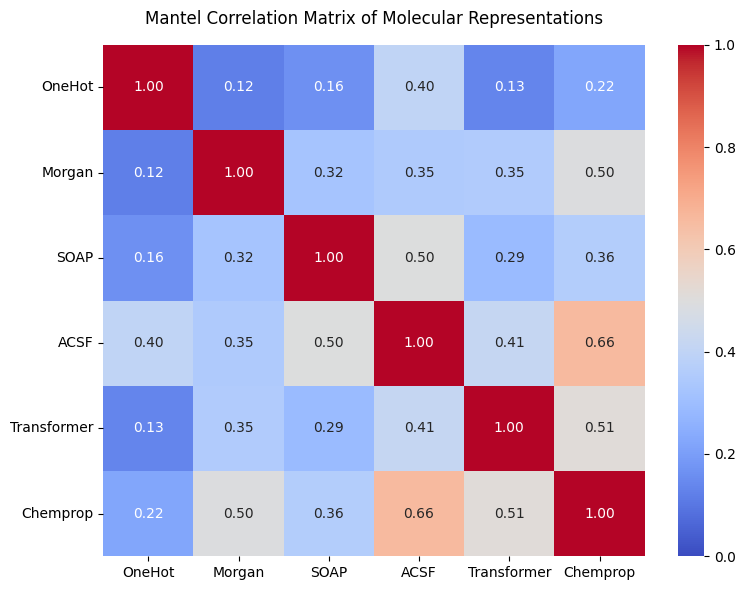

In [ ]:
df = pd.DataFrame(mantel_df, index=names)
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".2f", vmin=0, vmax=1)
plt.title("Mantel Correlation Matrix of Molecular Representations", pad=15)
plt.tight_layout()
#plt.savefig("mantel_heatmap.png", dpi=300)
plt.show()